# TEBD vs ED for the Open XXZ Chain

This notebook benchmarks finite-chain TEBD against exact dense evolution on a small open XXZ chain.

What it shows:
- `tebd_strang_evolution(...)` for a standard nearest-neighbor real-time evolution.
- `EDKit.mps2vec(...)` to convert the initial and evolved `MPS` states into dense vectors.
- `EDKit.ent_S(...)` to measure the exact bipartite entropy on the dense reference state.

The benchmark tracks fidelity to exact evolution, mid-chain entanglement entropy, and the final `maxlinkdim` reached by each TEBD run.


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit
using EDKit

default(; linewidth=2, legend=:bottomright)

function kron_all(ops)
    result = ops[1]
    for op in ops[2:end]
        result = kron(result, op)
    end
    return result
end

function dense_local_term(local_op::AbstractMatrix, left::Integer, nsites::Integer)
    span = round(Int, log2(size(local_op, 1)))
    ops = Matrix{ComplexF64}[]
    site = 1
    while site <= nsites
        if site == left
            push!(ops, ComplexF64.(local_op))
            site += span
        else
            push!(ops, Matrix{ComplexF64}(I, 2, 2))
            site += 1
        end
    end
    return kron_all(ops)
end

function dense_open_hamiltonian(nsites::Integer, Δ::Real)
    hbond = ComplexF64.(spinhalf_xyz_bond_hamiltonian(Jx=1.0, Jy=1.0, Jz=Δ))
    H = zeros(ComplexF64, 2^nsites, 2^nsites)
    for bond in 1:(nsites - 1)
        H .+= dense_local_term(hbond, bond, nsites)
    end
    return H
end

neel_state(sites) = MPS(sites, n -> isodd(n) ? "Up" : "Dn")

function exact_trajectory(vec0::AbstractVector, H::AbstractMatrix; dt::Real, nsteps::Integer)
    nsites = round(Int, log2(length(vec0)))
    basis = EDKit.TensorBasis(L=nsites, base=2)
    U = exp(-1im * dt * H)
    states = Vector{Vector{ComplexF64}}(undef, nsteps + 1)
    entropies = Vector{Float64}(undef, nsteps + 1)
    states[1] = ComplexF64.(vec0)
    entropies[1] = EDKit.ent_S(states[1], 1:(nsites ÷ 2), basis)
    for step in 1:nsteps
        states[step + 1] = U * states[step]
        entropies[step + 1] = EDKit.ent_S(states[step + 1], 1:(nsites ÷ 2), basis)
    end
    return (; times=dt .* collect(0:nsteps), states, entropies)
end

function tebd_trajectory(psi0::MPS; Δ::Real, dt::Real, nsteps::Integer, maxdim::Integer, cutoff::Real)
    nsites = length(psi0)
    # `nsites` is the chain length.
    # `dt` is the physical time step of one full odd-even-odd Strang sweep.
    # `local_hamiltonian(bond, weight)` returns the dense two-site XXZ term for one scheduled update.
    # `maxdim` and `cutoff` control TEBD compression after each gate application.
    evolution = tebd_strang_evolution(
        nsites,
        dt;
        local_hamiltonian=(bond, weight) -> weight * spinhalf_xyz_bond_hamiltonian(Jx=1.0, Jy=1.0, Jz=Δ),
        maxdim=maxdim,
        cutoff=cutoff,
    )
    psi = copy(psi0)
    states = Vector{Vector{ComplexF64}}(undef, nsteps + 1)
    entropies = Vector{Float64}(undef, nsteps + 1)
    states[1] = ComplexF64.(EDKit.mps2vec(psi))
    entropies[1] = bond_entropy(psi, length(psi) ÷ 2)
    for step in 1:nsteps
        evolve!(psi, evolution)
        states[step + 1] = ComplexF64.(EDKit.mps2vec(psi))
        entropies[step + 1] = bond_entropy(psi, length(psi) ÷ 2)
    end
    return (; times=dt .* collect(0:nsteps), states, entropies, maxlinkdim=maxlinkdim(psi))
end


tebd_trajectory (generic function with 1 method)

In [2]:
# `nsites=8` keeps the ED reference cheap enough to rerun interactively.
# `Δ=1.2` gives a nontrivial XXZ evolution without pushing the benchmark too close to a trivial limit.
# `dt=0.05` and `total_time=1.0` are small enough that TEBD should already be accurate at moderate `maxdim`.
# `maxdims` is the bond-dimension scan for the benchmark.
nsites = 8
Δ = 1.2
dt = 0.05
total_time = 1.0
nsteps = round(Int, total_time / dt)
maxdims = [4, 8, 16, 32]
cutoff = 1e-12

sites = siteinds("S=1/2", nsites)
psi0 = neel_state(sites)
vec0 = ComplexF64.(EDKit.mps2vec(psi0))
H = dense_open_hamiltonian(nsites, Δ)

exact = exact_trajectory(vec0, H; dt=dt, nsteps=nsteps)
trajectories = Dict(chi => tebd_trajectory(psi0; Δ=Δ, dt=dt, nsteps=nsteps, maxdim=chi, cutoff=cutoff) for chi in maxdims)

fidelities = Dict(
    chi => [abs2(dot(exact.states[i], trajectories[chi].states[i])) for i in eachindex(exact.states)]
    for chi in maxdims
)

summary_rows = [
    (
        chi=chi,
        final_fidelity=fidelities[chi][end],
        final_entropy=trajectories[chi].entropies[end],
        maxlinkdim=trajectories[chi].maxlinkdim,
    )
    for chi in maxdims
]

summary_rows


4-element Vector{@NamedTuple{chi::Int64, final_fidelity::Float64, final_entropy::Float64, maxlinkdim::Int64}}:
 (chi = 4, final_fidelity = 0.9999344412121094, final_entropy = 0.5113914958313434, maxlinkdim = 4)
 (chi = 8, final_fidelity = 0.9999998703948062, final_entropy = 0.5115688413710249, maxlinkdim = 8)
 (chi = 16, final_fidelity = 0.99999987980202, final_entropy = 0.5115690059478006, maxlinkdim = 12)
 (chi = 32, final_fidelity = 0.99999987980202, final_entropy = 0.5115690059478006, maxlinkdim = 12)

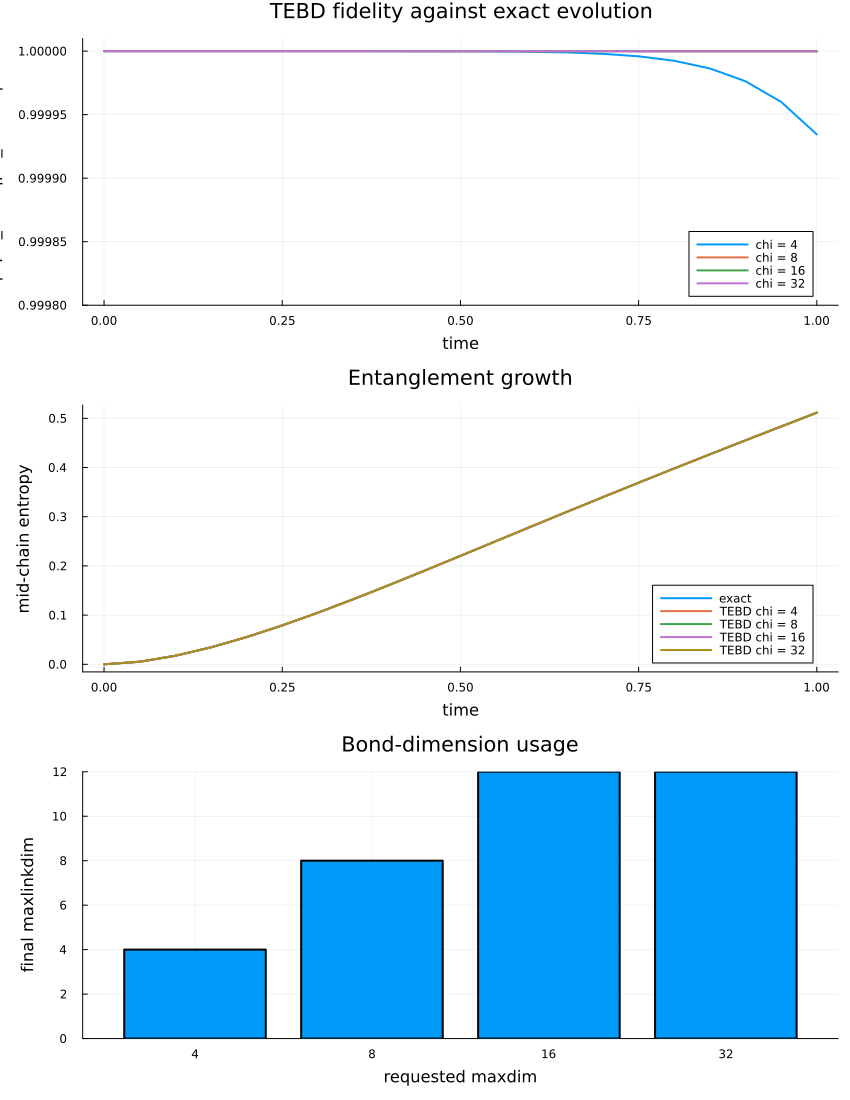

In [3]:
fidelity_plot = plot(
    exact.times,
    fidelities[maxdims[1]];
    xlabel="time",
    ylabel="|<psi_exact|psi_TEBD>|^2",
    label="chi = $(maxdims[1])",
    title="TEBD fidelity against exact evolution",
    ylim=(0.9998, 1.00001),
)
for chi in maxdims[2:end]
    plot!(fidelity_plot, exact.times, fidelities[chi]; label="chi = $chi")
end

entropy_plot = plot(
    exact.times,
    exact.entropies;
    xlabel="time",
    ylabel="mid-chain entropy",
    label="exact",
    title="Entanglement growth",
)
for chi in maxdims
    plot!(entropy_plot, trajectories[chi].times, trajectories[chi].entropies; label="TEBD chi = $chi")
end

maxlinkdim_plot = bar(
    string.(maxdims),
    [row.maxlinkdim for row in summary_rows];
    xlabel="requested maxdim",
    ylabel="final maxlinkdim",
    label="",
    title="Bond-dimension usage",
)

plot(fidelity_plot, entropy_plot, maxlinkdim_plot; layout=(3, 1), size=(850, 1100))
